In [1]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

In [2]:
CSV_PATH = "../data/ISIC_2020_Training_GroundTruth.csv"

TRAIN_DIR = "../data/images/train"
VAL_DIR = "../data/images/val"
TEST_DIR = "../data/images/test"

IMG_HEIGHT = 256
IMG_WIDTH = 256
BATCH_SIZE = 8
EPOCHS = 80

# A larger latent grid/codebook gives dermoscopy textures enough capacity to avoid
# collapsing to an average pink reconstruction.
LATENT_DIM = 128
NUM_EMBEDDINGS = 512
BETA = 0.25
LEARNING_RATE = 3e-4

# Generate variations by replacing a small fraction of discrete codes with codes
# observed in malignant training images, rather than adding noise to raw latents.
SYNTHETIC_CODE_MUTATION_RATE = 0.08
SYNTHETIC_CODE_TEMPERATURE = 0.7

SEED = 42

OUTPUT_DIR = Path("../outputs/figures")
GENERATED_DIR = OUTPUT_DIR / "generated"
RECON_DIR = OUTPUT_DIR / "reconstructions"
CODEBOOK_DIR = OUTPUT_DIR / "codebook_analysis"

GENERATED_DIR.mkdir(parents=True, exist_ok=True)
RECON_DIR.mkdir(parents=True, exist_ok=True)
CODEBOOK_DIR.mkdir(parents=True, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

AUTOTUNE = tf.data.AUTOTUNE


In [3]:
df = pd.read_csv(CSV_PATH)

df.head()

,image_name,patient_id,sex,age_approx,anatom_site_general_challenge,diagnosis,benign_malignant,target
0,ISIC_2637011,IP_7279968,male,45.0,head/neck,unknown,benign,0
1,ISIC_0015719,IP_3075186,female,45.0,upper extremity,unknown,benign,0
2,ISIC_0052212,IP_2842074,female,50.0,lower extremity,nevus,benign,0
3,ISIC_0068279,IP_6890425,female,45.0,head/neck,unknown,benign,0
4,ISIC_0074268,IP_8723313,female,55.0,upper extremity,unknown,benign,0


In [4]:
required_columns = {"image_name", "target"}
missing_columns = required_columns - set(df.columns)

if missing_columns:
    raise ValueError(f"CSV is missing required columns: {missing_columns}")

label_lookup = dict(
    zip(
        df["image_name"].astype(str),
        df["target"].astype(int)
    )
)

print("CSV loaded.")
print(f"Total rows: {len(df)}")
print("\nTarget distribution:")
print(df["target"].value_counts())

CSV loaded.
Total rows: 33126

Target distribution:
target
0    32542
1      584
Name: count, dtype: int64


In [5]:
VALID_EXTS = {".jpg", ".jpeg", ".png"}

def get_image_files(folder):
    folder = Path(folder)

    files = []

    for path in folder.rglob("*"):
        if not path.is_file():
            continue

        if path.suffix.lower() not in VALID_EXTS:
            continue

        if "__MACOSX" in str(path):
            continue

        files.append(str(path))

    files.sort()
    return files


def image_name_from_path(path):
    return Path(path).stem


def build_image_dataframe(folder):
    files = get_image_files(folder)

    records = []

    for file_path in files:
        image_name = image_name_from_path(file_path)

        if image_name not in label_lookup:
            continue

        records.append({
            "filepath": file_path,
            "image_name": image_name,
            "target": label_lookup[image_name]
        })

    return pd.DataFrame(records)

In [6]:
train_df = build_image_dataframe(TRAIN_DIR)
val_df = build_image_dataframe(VAL_DIR)
test_df = build_image_dataframe(TEST_DIR)

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

print("\nTrain distribution:")
print(train_df["target"].value_counts())

print("\nVal distribution:")
print(val_df["target"].value_counts())

print("\nTest distribution:")
print(test_df["target"].value_counts())

Train: 257
Val: 240
Test: 600

Train distribution:
target
0    253
1      4
Name: count, dtype: int64

Val distribution:
target
0    238
1      2
Name: count, dtype: int64

Test distribution:
target
0    593
1      7
Name: count, dtype: int64


In [7]:
def load_image(path):
    image_bytes = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image_bytes, channels=3)
    image = tf.image.resize(
        image,
        [IMG_HEIGHT, IMG_WIDTH],
        method=tf.image.ResizeMethod.LANCZOS3,
        antialias=True
    )
    image = tf.cast(image, tf.float32) / 255.0
    return tf.clip_by_value(image, 0.0, 1.0)


def load_image_for_autoencoder(path):
    image = load_image(path)

    # For an autoencoder, the input and target are the same image.
    return image, image


def create_dataset(paths, shuffle=False):
    dataset = tf.data.Dataset.from_tensor_slices(paths)

    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=len(paths),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(
        load_image_for_autoencoder,
        num_parallel_calls=AUTOTUNE
    )

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(AUTOTUNE)

    return dataset


In [8]:
train_paths = train_df["filepath"].tolist()
val_paths = val_df["filepath"].tolist()
test_paths = test_df["filepath"].tolist()

train_ds = create_dataset(train_paths, shuffle=True)
val_ds = create_dataset(val_paths, shuffle=False)
test_ds = create_dataset(test_paths, shuffle=False)

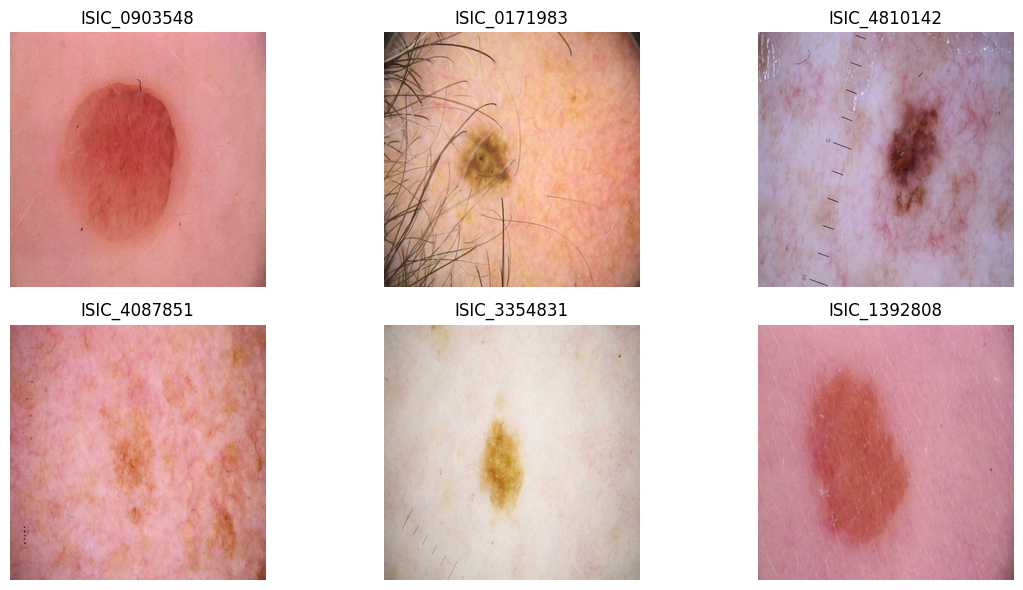

In [9]:
sample_paths = random.sample(train_paths, min(6, len(train_paths)))

plt.figure(figsize=(12, 6))

for i, path in enumerate(sample_paths):
    image = load_image(path).numpy()

    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title(Path(path).stem)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [10]:
@keras.utils.register_keras_serializable(package="MelanomaVQVAE")
class VectorQuantizer(layers.Layer):
    def __init__(self, num_embeddings, embedding_dim, beta=0.25, **kwargs):
        super().__init__(**kwargs)

        self.num_embeddings = num_embeddings
        self.embedding_dim = embedding_dim
        self.beta = beta

    def build(self, input_shape):
        self.embeddings = self.add_weight(
            shape=(self.num_embeddings, self.embedding_dim),
            initializer=keras.initializers.VarianceScaling(scale=1.0, mode="fan_avg", distribution="uniform"),
            trainable=True,
            name="vq_embeddings"
        )

    def call(self, inputs):
        input_shape = tf.shape(inputs)
        flat_inputs = tf.reshape(inputs, [-1, self.embedding_dim])
        encoding_indices = self.get_code_indices(flat_inputs)
        quantized = self.quantize_from_indices(encoding_indices)
        quantized = tf.reshape(quantized, input_shape)

        codebook_loss = tf.reduce_mean(
            tf.square(quantized - tf.stop_gradient(inputs))
        )
        commitment_loss = tf.reduce_mean(
            tf.square(tf.stop_gradient(quantized) - inputs)
        )

        self.add_loss(codebook_loss + self.beta * commitment_loss)

        # Straight-through estimator: decoder sees quantized codes, encoder gets gradients.
        return inputs + tf.stop_gradient(quantized - inputs)

    def get_code_indices(self, flat_inputs):
        flat_inputs = tf.cast(flat_inputs, tf.float32)

        distances = (
            tf.reduce_sum(tf.square(flat_inputs), axis=1, keepdims=True)
            + tf.reduce_sum(tf.square(self.embeddings), axis=1)
            - 2 * tf.matmul(flat_inputs, self.embeddings, transpose_b=True)
        )

        return tf.argmin(distances, axis=1)

    def quantize_from_indices(self, encoding_indices):
        return tf.gather(self.embeddings, encoding_indices)

    def get_config(self):
        config = super().get_config()
        config.update({
            "num_embeddings": self.num_embeddings,
            "embedding_dim": self.embedding_dim,
            "beta": self.beta,
        })
        return config


In [11]:
def residual_block(x, filters, name):
    shortcut = x

    x = layers.Conv2D(filters, 3, padding="same", use_bias=False, name=f"{name}_conv1")(x)
    x = layers.BatchNormalization(name=f"{name}_bn1")(x)
    x = layers.Activation("swish", name=f"{name}_swish1")(x)
    x = layers.Conv2D(filters, 3, padding="same", use_bias=False, name=f"{name}_conv2")(x)
    x = layers.BatchNormalization(name=f"{name}_bn2")(x)

    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, padding="same", use_bias=False, name=f"{name}_skip")(shortcut)

    x = layers.Add(name=f"{name}_add")([shortcut, x])
    return layers.Activation("swish", name=f"{name}_out")(x)


def downsample_block(x, filters, name):
    x = layers.Conv2D(filters, 4, strides=2, padding="same", use_bias=False, name=f"{name}_downsample")(x)
    x = layers.BatchNormalization(name=f"{name}_bn")(x)
    x = layers.Activation("swish", name=f"{name}_swish")(x)
    return residual_block(x, filters, name=f"{name}_res")


def create_encoder(input_shape, latent_dim):
    encoder_inputs = keras.Input(shape=input_shape)

    x = downsample_block(encoder_inputs, 64, name="encoder_block1")
    x = downsample_block(x, 128, name="encoder_block2")
    x = downsample_block(x, 256, name="encoder_block3")

    x = layers.Conv2D(latent_dim, 1, padding="same", name="encoder_projection")(x)
    encoded = layers.BatchNormalization(name="encoder_projection_bn")(x)

    encoder = keras.Model(
        encoder_inputs,
        encoded,
        name="encoder"
    )

    return encoder


In [12]:
def upsample_block(x, filters, name):
    x = layers.UpSampling2D(2, interpolation="bilinear", name=f"{name}_upsample")(x)
    x = layers.Conv2D(filters, 3, padding="same", use_bias=False, name=f"{name}_conv")(x)
    x = layers.BatchNormalization(name=f"{name}_bn")(x)
    x = layers.Activation("swish", name=f"{name}_swish")(x)
    return residual_block(x, filters, name=f"{name}_res")


def create_decoder(latent_shape):
    decoder_inputs = keras.Input(shape=latent_shape)

    x = layers.Conv2D(256, 3, padding="same", use_bias=False, name="decoder_input_conv")(decoder_inputs)
    x = layers.BatchNormalization(name="decoder_input_bn")(x)
    x = layers.Activation("swish", name="decoder_input_swish")(x)
    x = residual_block(x, 256, name="decoder_input_res")

    x = upsample_block(x, 128, name="decoder_block1")
    x = upsample_block(x, 64, name="decoder_block2")
    x = upsample_block(x, 32, name="decoder_block3")

    x = layers.Conv2D(32, 3, activation="swish", padding="same", name="decoder_refine")(x)
    decoder_outputs = layers.Conv2D(
        3,
        3,
        activation="sigmoid",
        padding="same",
        name="decoder_rgb"
    )(x)

    decoder = keras.Model(
        decoder_inputs,
        decoder_outputs,
        name="decoder"
    )

    return decoder


In [13]:
def connect_vqvae_model(encoder, vector_quantizer, decoder, input_shape):
    vqvae_inputs = keras.Input(shape=input_shape)

    encoded = encoder(vqvae_inputs)

    quantized = vector_quantizer(encoded)

    reconstructed = decoder(quantized)

    vqvae = keras.Model(
        vqvae_inputs,
        reconstructed,
        name="vqvae"
    )

    return vqvae

In [14]:
input_shape = (IMG_HEIGHT, IMG_WIDTH, 3)

encoder = create_encoder(
    input_shape=input_shape,
    latent_dim=LATENT_DIM
)

latent_shape = encoder.output_shape[1:]

print("Latent shape:", latent_shape)

vector_quantizer = VectorQuantizer(
    num_embeddings=NUM_EMBEDDINGS,
    embedding_dim=LATENT_DIM,
    beta=BETA,
    name="vector_quantizer"
)

decoder = create_decoder(latent_shape)

vqvae = connect_vqvae_model(
    encoder=encoder,
    vector_quantizer=vector_quantizer,
    decoder=decoder,
    input_shape=input_shape
)

Latent shape: (32, 32, 128)


In [15]:
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_block1_dow… │ (None, 128, 128,  │      3,072 │ input_layer[0][0] │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_block1_bn   │ (None, 128, 128,  │        256 │ encoder_block1_d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_block1_swi… │ (None, 128, 128,  │          0 │ encoder_block1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_block1_res… │ (None, 128, 128,  │     36,864 │ encoder_block1_s… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_block1_res… │ (None, 128, 128,  │        256 │ encoder_block1_r… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_block1_res… │ (None, 128, 128,  │          0 │ encoder_block1_r… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_block1_res… │ (None, 128, 128,  │     36,864 │ encoder_block1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_block1_res… │ (None, 128, 128,  │        256 │ encoder_block1_r… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_block1_res… │ (None, 128, 128,  │          0 │ encoder_block1_s… │
│ (Add)               │ 64)               │            │ encoder_block1_r… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_block1_res… │ (None, 128, 128,  │          0 │ encoder_block1_r… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_block2_dow… │ (None, 64, 64,    │    131,072 │ encoder_block1_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_block2_bn   │ (None, 64, 64,    │        512 │ encoder_block2_d… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_block2_swi… │ (None, 64, 64,    │          0 │ encoder_block2_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_block2_res… │ (None, 64, 64,    │    147,456 │ encoder_block2_s… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_block2_res… │ (None, 64, 64,    │        512 │ encoder_block2_r… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_block2_res… │ (None, 64, 64,    │          0 │ encoder_block2_r

 Total params: 2,245,504 (8.57 MB)

 Trainable params: 2,242,560 (8.55 MB)

 Non-trainable params: 2,944 (11.50 KB)

In [16]:
decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 32, 32,    │          0 │ -                 │
│ (InputLayer)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input_conv  │ (None, 32, 32,    │    294,912 │ input_layer_1[0]… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input_bn    │ (None, 32, 32,    │      1,024 │ decoder_input_co… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input_swish │ (None, 32, 32,    │          0 │ decoder_input_bn… │
│ (Activation)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input_res_… │ (None, 32, 32,    │    589,824 │ decoder_input_sw… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input_res_… │ (None, 32, 32,    │      1,024 │ decoder_input_re… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input_res_… │ (None, 32, 32,    │          0 │ decoder_input_re… │
│ (Activation)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input_res_… │ (None, 32, 32,    │    589,824 │ decoder_input_re… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input_res_… │ (None, 32, 32,    │      1,024 │ decoder_input_re… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input_res_… │ (None, 32, 32,    │          0 │ decoder_input_sw… │
│ (Add)               │ 256)              │            │ decoder_input_re… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input_res_… │ (None, 32, 32,    │          0 │ decoder_input_re… │
│ (Activation)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_block1_ups… │ (None, 64, 64,    │          0 │ decoder_input_re… │
│ (UpSampling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_block1_conv │ (None, 64, 64,    │    294,912 │ decoder_block1_u… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_block1_bn   │ (None, 64, 64,    │        512 │ decoder_block1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_block1_swi… │ (None, 64, 64,    │          0 │ decoder_block1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_block1_res… │ (None, 64, 64,    │    147,456 │ decoder_block1_s… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_block1_res… │ (None, 64, 64,    │        512 │ decoder_block1_r

 Total params: 2,264,579 (8.64 MB)

 Trainable params: 2,261,699 (8.63 MB)

 Non-trainable params: 2,880 (11.25 KB)

In [17]:
vqvae.summary()

Model: "vqvae"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Functional)            │ (None, 32, 32, 128)    │     2,245,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vector_quantizer                │ (None, 32, 32, 128)    │        65,536 │
│ (VectorQuantizer)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 256, 256, 3)    │     2,264,579 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,575,619 (17.45 MB)

 Trainable params: 4,569,795 (17.43 MB)

 Non-trainable params: 5,824 (22.75 KB)

In [18]:
@keras.utils.register_keras_serializable(package="MelanomaVQVAE")
def vqvae_reconstruction_loss(y_true, y_pred):
    l1_loss = tf.reduce_mean(tf.abs(y_true - y_pred))
    ssim_loss = tf.reduce_mean(1.0 - tf.image.ssim(y_true, y_pred, max_val=1.0))
    return l1_loss + 0.5 * ssim_loss


vqvae.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE, clipnorm=1.0),
    loss=vqvae_reconstruction_loss,
    metrics=[keras.metrics.MeanAbsoluteError(name="mae")]
)


In [19]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=4,
        min_lr=1e-6
    )
]


In [20]:
history = vqvae.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/80
33/33 ━━━━━━━━━━━━━━━━━━━━ 140s 4s/step - loss: 1.3923 - mae: 0.1151 - val_loss: 0.3444 - val_mae: 0.1465 - learning_rate: 3.0000e-04
Epoch 2/80
33/33 ━━━━━━━━━━━━━━━━━━━━ 126s 4s/step - loss: 1.0600 - mae: 0.0707 - val_loss: 0.3260 - val_mae: 0.1175 - learning_rate: 3.0000e-04
Epoch 3/80
33/33 ━━━━━━━━━━━━━━━━━━━━ 117s 4s/step - loss: 0.7590 - mae: 0.0696 - val_loss: 0.3588 - val_mae: 0.1120 - learning_rate: 3.0000e-04
Epoch 4/80
33/33 ━━━━━━━━━━━━━━━━━━━━ 127s 4s/step - loss: 0.5656 - mae: 0.0646 - val_loss: 0.3657 - val_mae: 0.1177 - learning_rate: 3.0000e-04
Epoch 5/80
33/33 ━━━━━━━━━━━━━━━━━━━━ 136s 4s/step - loss: 0.4602 - mae: 0.0668 - val_loss: 0.3481 - val_mae: 0.1112 - learning_rate: 3.0000e-04
Epoch 6/80
33/33 ━━━━━━━━━━━━━━━━━━━━ 140s 4s/step - loss: 0.3820 - mae: 0.0641 - val_loss: 0.3254 - val_mae: 0.1104 - learning_rate: 3.0000e-04
Epoch 7/80
33/33 ━━━━━━━━━━━━━━━━━━━━ 120s 4s/step - loss: 0.3400 - mae: 0.0645 - val_loss: 0.3054 - val_mae: 0.1002 - learning_ra

In [21]:
Path("../outputs").mkdir(parents=True, exist_ok=True)

vqvae.save_weights("../outputs/vqvae.weights.h5")

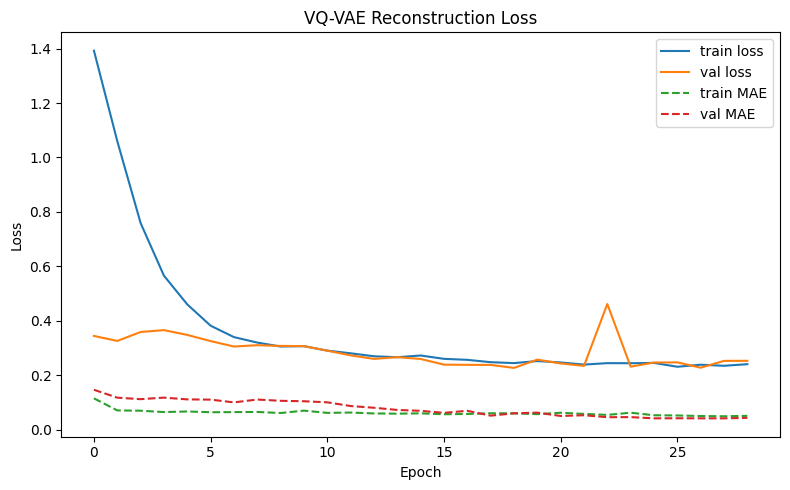

In [22]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="train loss")

if "val_loss" in history.history:
    plt.plot(history.history["val_loss"], label="val loss")

if "mae" in history.history:
    plt.plot(history.history["mae"], label="train MAE", linestyle="--")

if "val_mae" in history.history:
    plt.plot(history.history["val_mae"], label="val MAE", linestyle="--")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VQ-VAE Reconstruction Loss")
plt.legend()
plt.tight_layout()

plt.savefig(OUTPUT_DIR / "vqvae_training_loss.png")
plt.show()


In [23]:
def load_image_as_numpy(path):
    image = load_image(path)
    return image.numpy()

In [24]:
def show_reconstructions(model, paths, n=6):
    sample_paths = random.sample(paths, min(n, len(paths)))

    original_images = np.array([
        load_image_as_numpy(path) for path in sample_paths
    ])

    reconstructed_images = model.predict(
        original_images,
        verbose=0
    )

    n_images = len(sample_paths)

    plt.figure(figsize=(3 * n_images, 6))

    for i in range(n_images):
        plt.subplot(2, n_images, i + 1)
        plt.imshow(original_images[i])
        plt.title("Original")
        plt.axis("off")

        plt.subplot(2, n_images, i + 1 + n_images)
        plt.imshow(np.clip(reconstructed_images[i], 0, 1))
        plt.title("Reconstructed")
        plt.axis("off")

    plt.tight_layout()
    plt.savefig(RECON_DIR / "original_vs_reconstructed.png")
    plt.show()

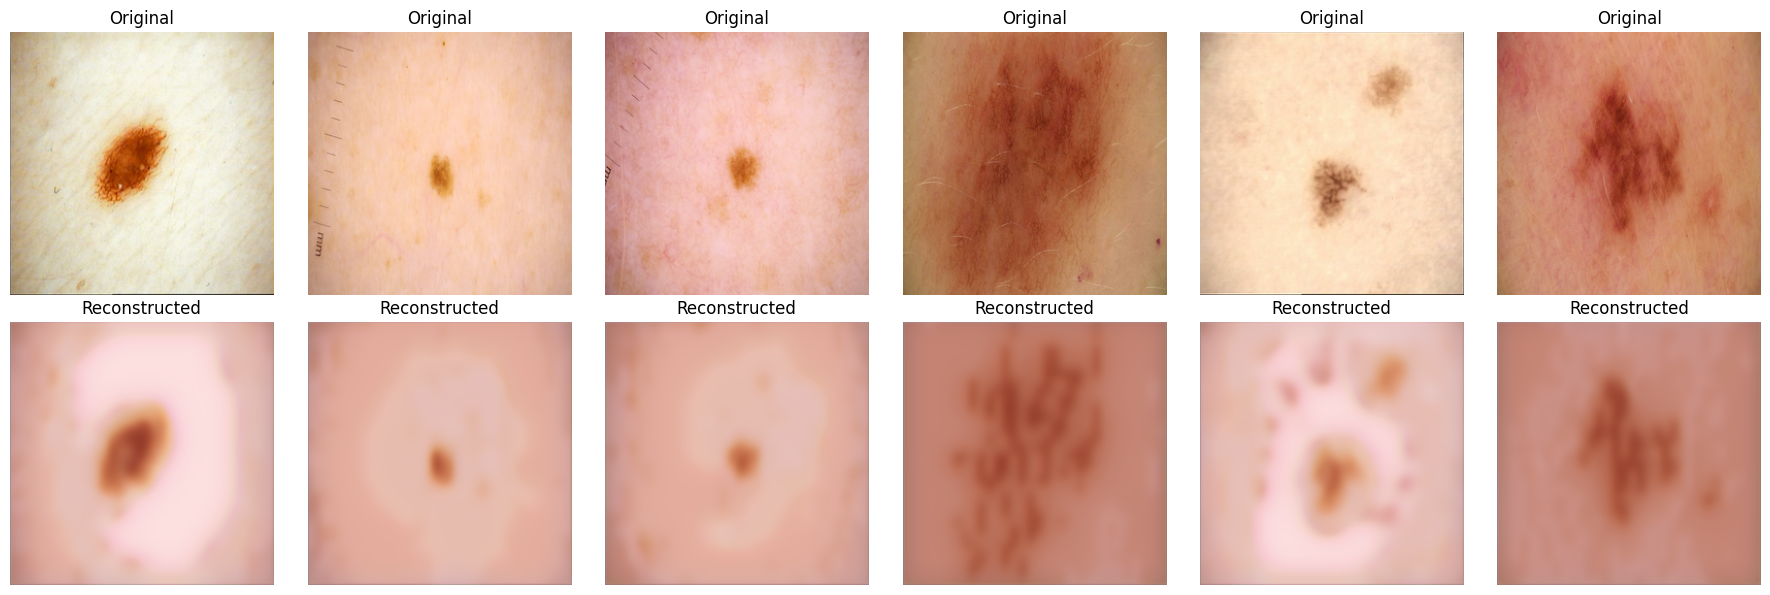

In [25]:
show_reconstructions(vqvae, test_paths, n=6)

In [26]:
def get_code_indices_for_image(image):
    image_batch = np.expand_dims(image, axis=0)

    z = encoder.predict(
        image_batch,
        verbose=0
    )

    flat_z = z.reshape(-1, LATENT_DIM)

    code_indices = vector_quantizer.get_code_indices(
        tf.convert_to_tensor(flat_z, dtype=tf.float32)
    ).numpy()

    code_indices = code_indices.reshape(
        z.shape[1],
        z.shape[2]
    )

    return code_indices

In [27]:
def decode_from_code_indices(code_indices):
    code_indices = np.asarray(code_indices, dtype=np.int32)

    if code_indices.ndim == 2:
        code_indices = np.expand_dims(code_indices, axis=0)

    flat_indices = tf.reshape(tf.convert_to_tensor(code_indices), [-1])
    quantized = vector_quantizer.quantize_from_indices(flat_indices)
    quantized = tf.reshape(
        quantized,
        [code_indices.shape[0], code_indices.shape[1], code_indices.shape[2], LATENT_DIM]
    )

    decoded = decoder.predict(
        quantized,
        verbose=0
    )

    return decoded[0] if decoded.shape[0] == 1 else decoded


def decode_from_latent(z):
    quantized = vector_quantizer(
        tf.convert_to_tensor(z, dtype=tf.float32)
    )

    decoded = decoder.predict(
        quantized,
        verbose=0
    )[0]

    return decoded


In [28]:
def sample_codes_from_distribution(code_counts, size, temperature=1.0):
    counts = np.asarray(code_counts, dtype=np.float64) + 1e-6
    probs = counts / counts.sum()

    if temperature != 1.0:
        probs = np.power(probs, 1.0 / temperature)
        probs = probs / probs.sum()

    return np.random.choice(
        np.arange(len(probs)),
        size=size,
        replace=True,
        p=probs
    )


def get_code_indices_for_paths(paths, batch_size=8):
    all_code_indices = []

    for start in range(0, len(paths), batch_size):
        batch_paths = paths[start:start + batch_size]
        batch_images = np.array([
            load_image_as_numpy(path) for path in batch_paths
        ])

        z = encoder.predict(
            batch_images,
            verbose=0
        )

        flat_z = z.reshape(-1, LATENT_DIM)
        code_indices = vector_quantizer.get_code_indices(
            tf.convert_to_tensor(flat_z, dtype=tf.float32)
        ).numpy()

        code_indices = code_indices.reshape(
            z.shape[0],
            -1
        )
        all_code_indices.append(code_indices)

    return np.vstack(all_code_indices)


def get_code_counts_for_paths(paths, batch_size=8):
    counts = np.zeros(NUM_EMBEDDINGS, dtype=np.int64)

    for start in range(0, len(paths), batch_size):
        batch_paths = paths[start:start + batch_size]
        batch_images = np.array([
            load_image_as_numpy(path) for path in batch_paths
        ])

        z = encoder.predict(
            batch_images,
            verbose=0
        )

        flat_z = z.reshape(-1, LATENT_DIM)
        code_indices = vector_quantizer.get_code_indices(
            tf.convert_to_tensor(flat_z, dtype=tf.float32)
        ).numpy()

        counts += np.bincount(
            code_indices,
            minlength=NUM_EMBEDDINGS
        )

    return counts


def build_code_count_distribution(paths, batch_size=8):
    return get_code_counts_for_paths(paths, batch_size=batch_size)


def mutate_code_grid(code_indices, code_counts, mutation_rate=0.08, temperature=0.7):
    mutated = np.array(code_indices, copy=True)
    mutation_mask = np.random.random(mutated.shape) < mutation_rate
    n_mutations = int(mutation_mask.sum())

    if n_mutations == 0:
        return mutated

    mutated[mutation_mask] = sample_codes_from_distribution(
        code_counts,
        size=n_mutations,
        temperature=temperature
    )

    return mutated


def summarize_image_channels(images, label):
    images = np.asarray(images)
    means = images.mean(axis=(0, 1, 2))
    stds = images.std(axis=(0, 1, 2))
    print(f"{label} RGB mean:", np.round(means, 4))
    print(f"{label} RGB std:", np.round(stds, 4))


def generate_synthetic_malignant_images(
    source_df,
    n_images=10,
    mutation_rate=SYNTHETIC_CODE_MUTATION_RATE,
    temperature=SYNTHETIC_CODE_TEMPERATURE
):
    malignant_df = source_df[source_df["target"] == 1]

    if len(malignant_df) == 0:
        print("No malignant images found.")
        return

    malignant_paths = malignant_df["filepath"].tolist()
    malignant_code_counts = build_code_count_distribution(malignant_paths)

    sample_df = malignant_df.sample(
        n=min(n_images, len(malignant_df)),
        random_state=SEED
    )

    originals = []
    synthetics = []

    for i, row in enumerate(sample_df.itertuples(), start=1):
        original = load_image_as_numpy(row.filepath)
        code_indices = get_code_indices_for_image(original)
        mutated_code_indices = mutate_code_grid(
            code_indices,
            malignant_code_counts,
            mutation_rate=mutation_rate,
            temperature=temperature
        )

        synthetic = decode_from_code_indices(mutated_code_indices)
        synthetic = np.clip(synthetic, 0, 1)

        originals.append(original)
        synthetics.append(synthetic)

        synthetic_path = GENERATED_DIR / f"synthetic_malignant_{i:02d}.png"
        comparison_path = GENERATED_DIR / f"comparison_malignant_{i:02d}.png"

        plt.imsave(
            synthetic_path,
            synthetic
        )

        plt.figure(figsize=(8, 4))

        plt.subplot(1, 2, 1)
        plt.imshow(original)
        plt.title("Original malignant")
        plt.axis("off")

        plt.subplot(1, 2, 2)
        plt.imshow(synthetic)
        plt.title("Synthetic code variation")
        plt.axis("off")

        plt.tight_layout()
        plt.savefig(comparison_path)
        plt.close()

    summarize_image_channels(originals, "Original malignant samples")
    summarize_image_channels(synthetics, "Synthetic malignant samples")
    print(f"Generated images saved to: {GENERATED_DIR}")


In [29]:
generation_df = pd.concat(
    [train_df, val_df],
    ignore_index=True
)

generate_synthetic_malignant_images(
    source_df=generation_df,
    n_images=10,
    mutation_rate=SYNTHETIC_CODE_MUTATION_RATE,
    temperature=SYNTHETIC_CODE_TEMPERATURE
)


Original malignant samples RGB mean: [0.7457 0.5908 0.5553]
Original malignant samples RGB std: [0.1199 0.1134 0.1601]
Synthetic malignant samples RGB mean: [0.8162 0.5857 0.5229]
Synthetic malignant samples RGB std: [0.0587 0.0763 0.0877]
Generated images saved to: ../outputs/figures/generated


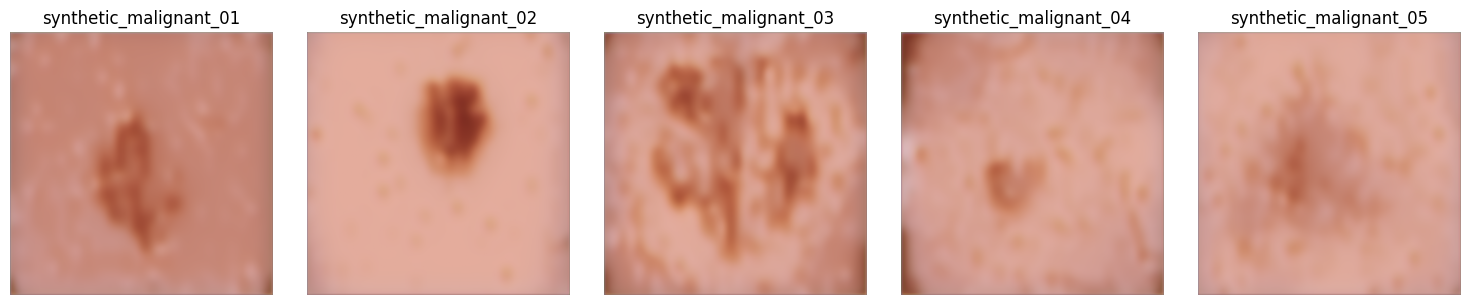

In [30]:
generated_files = sorted(
    GENERATED_DIR.glob("synthetic_malignant_*.png")
)

n = min(5, len(generated_files))

if n > 0:
    plt.figure(figsize=(3 * n, 3))

    for i, path in enumerate(generated_files[:n]):
        img = plt.imread(path)

        plt.subplot(1, n, i + 1)
        plt.imshow(img)
        plt.title(path.stem)
        plt.axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("No generated files found.")

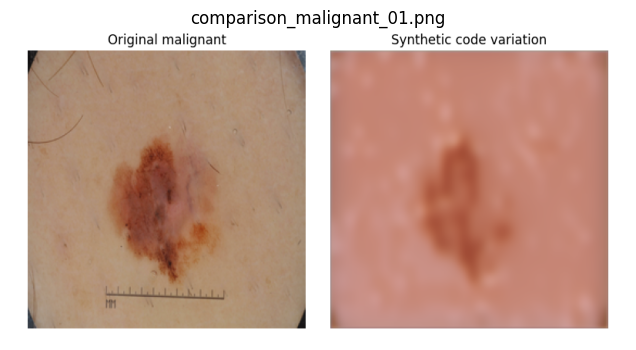

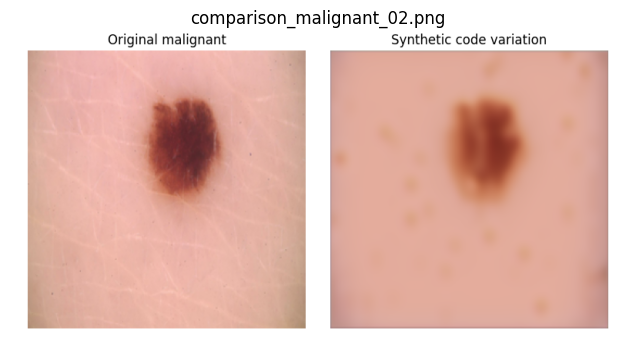

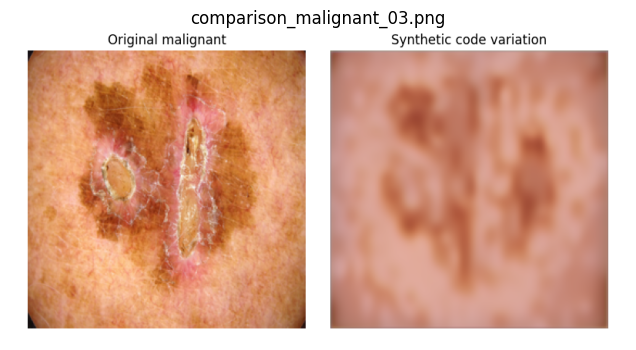

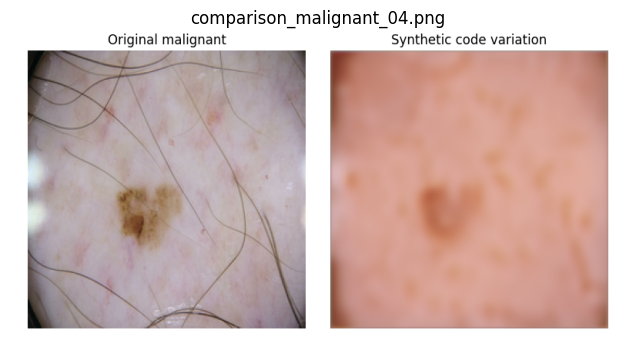

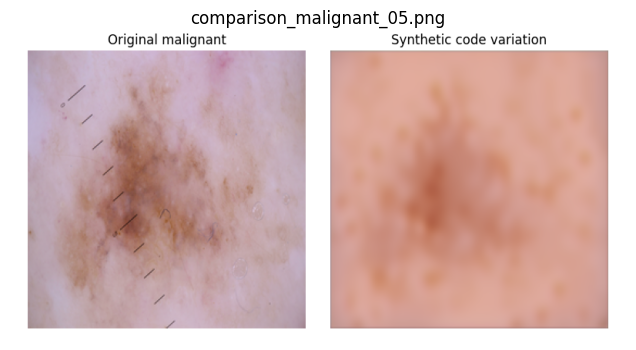

In [31]:
comparison_files = sorted(
    GENERATED_DIR.glob("comparison_malignant_*.png")
)

n = min(5, len(comparison_files))

for path in comparison_files[:n]:
    img = plt.imread(path)

    plt.figure(figsize=(8, 4))
    plt.imshow(img)
    plt.title(path.name)
    plt.axis("off")
    plt.show()

In [32]:
# get_code_indices_for_paths is defined above so generation and analysis both run top-to-bottom.


In [33]:
def compare_codebook_usage(source_df):
    benign_df = source_df[source_df["target"] == 0]
    malignant_df = source_df[source_df["target"] == 1]

    benign_paths = benign_df["filepath"].tolist()
    malignant_paths = malignant_df["filepath"].tolist()

    print("Benign images:", len(benign_paths))
    print("Malignant images:", len(malignant_paths))

    benign_counts = get_code_counts_for_paths(benign_paths)
    malignant_counts = get_code_counts_for_paths(malignant_paths)

    benign_freq = benign_counts / benign_counts.sum()
    malignant_freq = malignant_counts / malignant_counts.sum()

    all_counts = benign_counts + malignant_counts
    all_freq = all_counts / all_counts.sum()
    active_codes = int(np.sum(all_counts > 0))
    perplexity = float(np.exp(-np.sum(all_freq[all_freq > 0] * np.log(all_freq[all_freq > 0]))))

    codebook_df = pd.DataFrame({
        "codebook_index": np.arange(NUM_EMBEDDINGS),
        "benign_count": benign_counts,
        "malignant_count": malignant_counts,
        "benign_frequency": benign_freq,
        "malignant_frequency": malignant_freq,
        "malignant_minus_benign": malignant_freq - benign_freq
    })

    codebook_df = codebook_df.sort_values(
        "malignant_minus_benign",
        ascending=False
    )

    output_path = CODEBOOK_DIR / "codebook_usage_benign_vs_malignant.csv"

    codebook_df.to_csv(
        output_path,
        index=False
    )

    print(f"Active codebook entries: {active_codes}/{NUM_EMBEDDINGS}")
    print(f"Codebook perplexity: {perplexity:.2f}")
    print(f"Saved codebook usage CSV to: {output_path}")

    return codebook_df


In [34]:
analysis_df = pd.concat(
    [train_df, val_df, test_df],
    ignore_index=True
)

codebook_df = compare_codebook_usage(analysis_df)

codebook_df.head(10)

Benign images: 1084
Malignant images: 13
Active codebook entries: 18/512
Codebook perplexity: 7.37
Saved codebook usage CSV to: ../outputs/figures/codebook_analysis/codebook_usage_benign_vs_malignant.csv


,codebook_index,benign_count,malignant_count,benign_frequency,malignant_frequency,malignant_minus_benign
19,19,213985,5481,0.192777,0.411734,0.218957
354,354,46803,852,0.042164,0.064002,0.021838
34,34,2293,60,0.002066,0.004507,0.002441
352,352,55,5,0.000050,0.000376,0.000326
417,417,189,6,0.000170,0.000451,0.000280
55,55,971,12,0.000875,0.000901,0.000027
49,49,65,1,0.000059,0.000075,0.000017
347,347,0,0,0.000000,0.000000,0.000000
346,346,0,0,0.000000,0.000000,0.000000
345,345,0,0,0.000000,0.000000,0.000000


In [35]:
codebook_df.tail(10).sort_values("malignant_minus_benign")

,codebook_index,benign_count,malignant_count,benign_frequency,malignant_frequency,malignant_minus_benign
74,74,117422,252,1.057841e-01,0.018930,-8.685377e-02
162,162,95015,123,8.559787e-02,0.009240,-7.635808e-02
487,487,90122,569,8.118982e-02,0.042743,-3.844643e-02
318,318,239795,2574,2.160284e-01,0.193359,-2.266904e-02
28,28,165265,1850,1.488852e-01,0.138972,-9.912886e-03
175,175,138019,1527,1.243396e-01,0.114709,-9.631116e-03
443,443,7,0,6.306215e-06,0.000000,-6.306215e-06
217,217,6,0,5.405327e-06,0.000000,-5.405327e-06
184,184,2,0,1.801776e-06,0.000000,-1.801776e-06
461,461,1,0,9.008879e-07,0.000000,-9.008879e-07


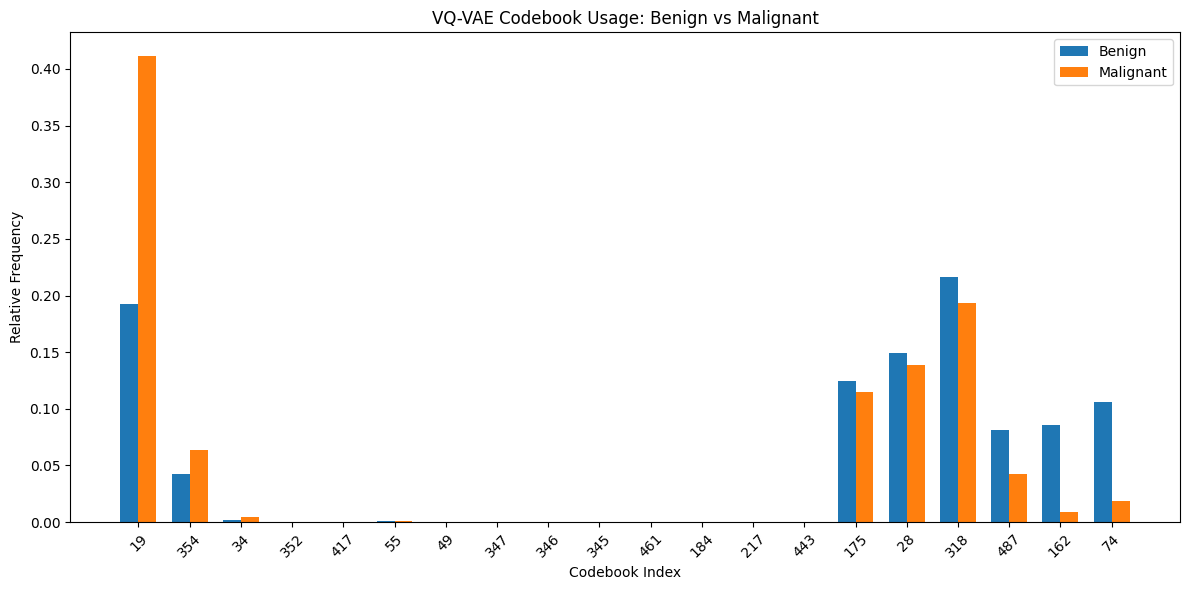

In [36]:
top_malignant_codes = codebook_df.head(10)
top_benign_codes = codebook_df.tail(10)

plot_df = pd.concat([
    top_malignant_codes,
    top_benign_codes
])

plt.figure(figsize=(12, 6))

x = np.arange(len(plot_df))
width = 0.35

plt.bar(
    x - width / 2,
    plot_df["benign_frequency"],
    width,
    label="Benign"
)

plt.bar(
    x + width / 2,
    plot_df["malignant_frequency"],
    width,
    label="Malignant"
)

plt.xticks(
    x,
    plot_df["codebook_index"].astype(str),
    rotation=45
)

plt.xlabel("Codebook Index")
plt.ylabel("Relative Frequency")
plt.title("VQ-VAE Codebook Usage: Benign vs Malignant")
plt.legend()
plt.tight_layout()

plt.savefig(
    CODEBOOK_DIR / "codebook_usage_benign_vs_malignant.png"
)

plt.show()

In [37]:
Path("../outputs/models").mkdir(parents=True, exist_ok=True)

encoder.save("../outputs/models/vqvae_encoder.keras")
decoder.save("../outputs/models/vqvae_decoder.keras")
vqvae.save("../outputs/models/vqvae_full_model.keras")

In [38]:
print("VQ-VAE experiment complete.")
print(f"Reconstructions saved to: {RECON_DIR}")
print(f"Generated images saved to: {GENERATED_DIR}")
print(f"Codebook analysis saved to: {CODEBOOK_DIR}")

VQ-VAE experiment complete.
Reconstructions saved to: ../outputs/figures/reconstructions
Generated images saved to: ../outputs/figures/generated
Codebook analysis saved to: ../outputs/figures/codebook_analysis
